# Data Visualization

**Goal:** Turn the cleaned Titanic data into insights using Matplotlib and Seaborn — the two libraries every ML practitioner must know.

**Why it matters:** Numbers in a table hide patterns. A good chart reveals them in 2 seconds. Before modeling, you must *see* your data — distributions, relationships, correlations, and outliers.

**Prerequisite:** [02-data-cleaning.ipynb](./02-data-cleaning.ipynb)

**Dataset:** We'll reload and re-clean quickly so this notebook is self-contained.

---

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global style — set once, applies to all plots
sns.set_style("whitegrid")
sns.set_palette("deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# Reproducibility for any random sampling later
np.random.seed(42)

print("matplotlib:", plt.matplotlib.__version__)
print("seaborn   :", sns.__version__)

matplotlib: 3.11.1
seaborn   : 0.13.2


##  Reload & Quick Clean

To keep this notebook independent, we re-run the essential cleaning steps from the previous notebook.

In [39]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Minimal cleaning — same decisions as before
df["HasCabin"] = df["Cabin"].notna().astype(int)
df = df.drop(columns=["Cabin"])
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(lambda x: x.fillna(x.median()))
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Fare_log"] = np.log1p(df["Fare"])
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

print("Shape:", df.shape)
print("Missing:", df.isnull().sum().sum())
df.head(3)

Shape: (891, 14)
Missing: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin,Fare_log,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2.110213,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,4.280593,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,2.188856,1


##  Distributions — Understanding Single Variables

The first question about any numeric feature: **what shape is it?**

We'll look at `Age` and `Fare` (raw and log).

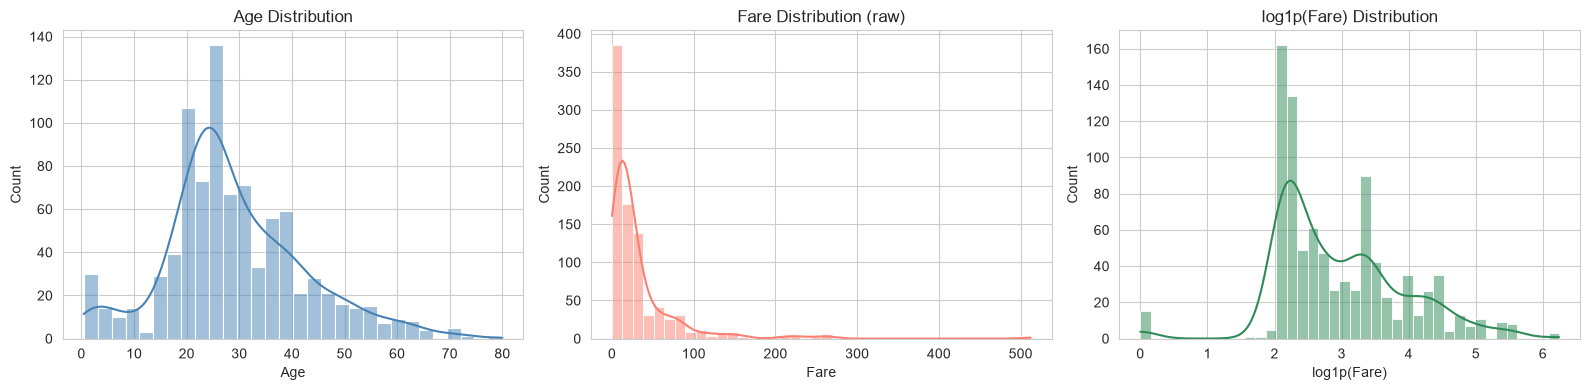

In [40]:
fig , axes = plt.subplots(1,3,figsize=(16, 4))
# Age
sns.histplot(df["Age"], bins=30 , kde=True , ax=axes[0], color="steelblue" )
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

# Fare 
sns.histplot(df["Fare"], bins=40, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Fare Distribution (raw)")
axes[1].set_xlabel("Fare")

# log1p(Fare)
sns.histplot(df["Fare_log"], bins=40, kde=True, ax=axes[2], color="seagreen")
axes[2].set_title("log1p(Fare) Distribution")
axes[2].set_xlabel("log1p(Fare)")

plt.tight_layout()
plt.show()

## Categorical Distributions — Counts

For categorical features, the right chart is a **countplot** — how many of each?

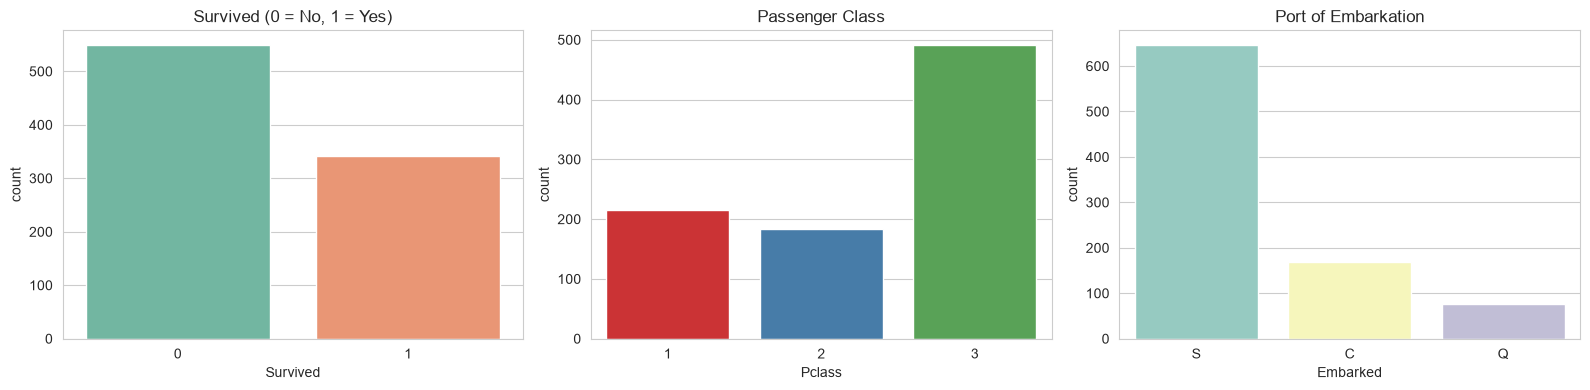

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df, x="Survived", ax=axes[0], hue="Survived",  palette="Set2", legend=False)
axes[0].set_title("Survived (0 = No, 1 = Yes)")

sns.countplot(data=df, x="Pclass", ax=axes[1], hue="Pclass", palette="Set1", legend=False)
axes[1].set_title("Passenger Class")

sns.countplot(data=df, x="Embarked", ax=axes[2], hue="Embarked", palette="Set3", legend=False)
axes[2].set_title("Port of Embarkation")

plt.tight_layout()
plt.show()

## Bivariate Analysis — Feature vs Target

The key question: **does this feature separate survivors from non-survivors?**


C:\Users\Online\AppData\Local\Temp\ipykernel_24264\3280884136.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Sex", y="Survived", ax=axes[1], palette="Set2", errorbar=None )


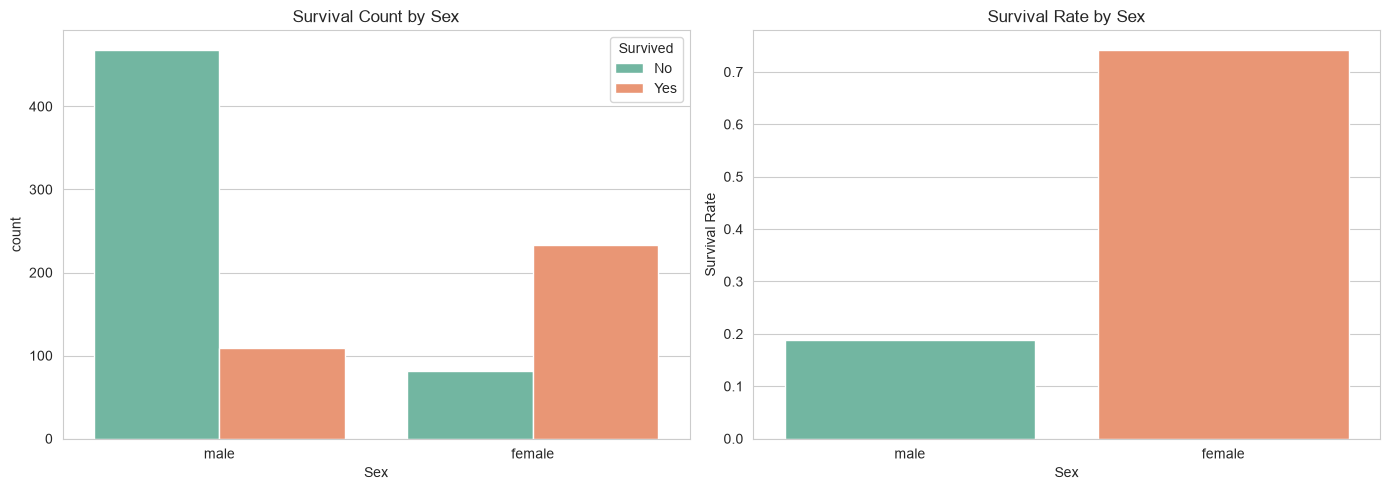

Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.countplot(data=df, x="Sex", hue="Survived", ax=axes[0], palette="Set2")
axes[0].set_title("Survival Count by Sex")
axes[0].legend(title="Survived", labels=["No", "Yes"])


sns.barplot(data=df, x="Sex", y="Survived", ax=axes[1], palette="Set2", errorbar=None )
axes[1].set_title("Survival Rate by Sex")
axes[1].set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()


print(df.groupby("Sex", observed=True)["Survived"].mean().round(3))


C:\Users\Online\AppData\Local\Temp\ipykernel_24264\3512633672.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Pclass", y="Survived", ax=axes[1], palette="viridis", errorbar=None)


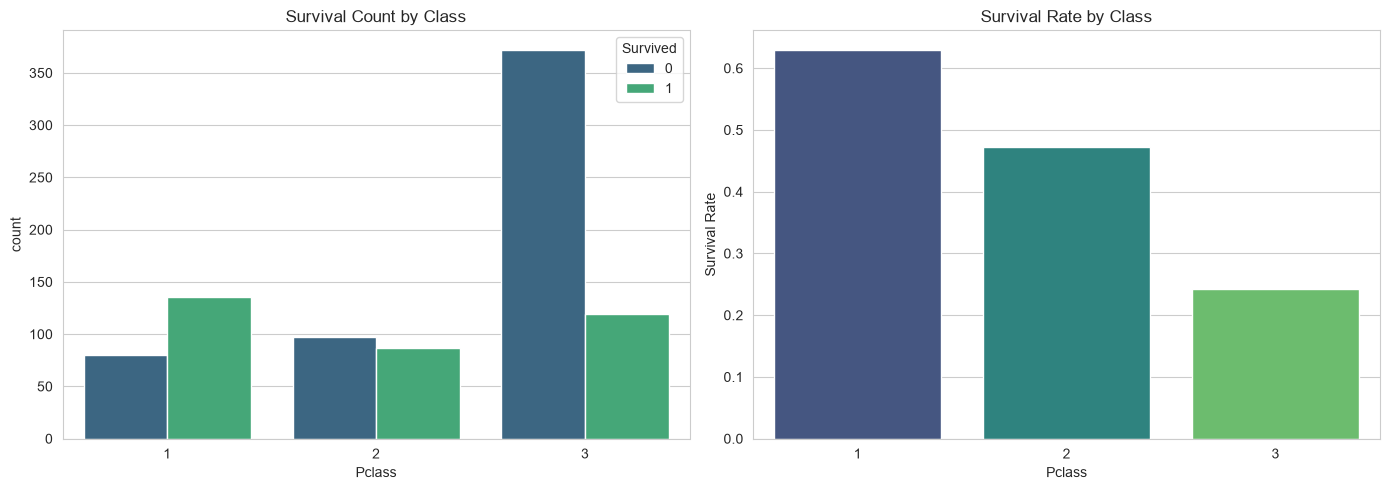

Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="Pclass", hue="Survived", ax=axes[0], palette="viridis")
axes[0].set_title("Survival Count by Class")

sns.barplot(data=df, x="Pclass", y="Survived", ax=axes[1], palette="viridis", errorbar=None)
axes[1].set_title("Survival Rate by Class")
axes[1].set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()

print(df.groupby("Pclass", observed=True)["Survived"].mean().round(3))

##  Interaction Effect — Sex × Pclass

Sometimes two features together reveal what neither shows alone.

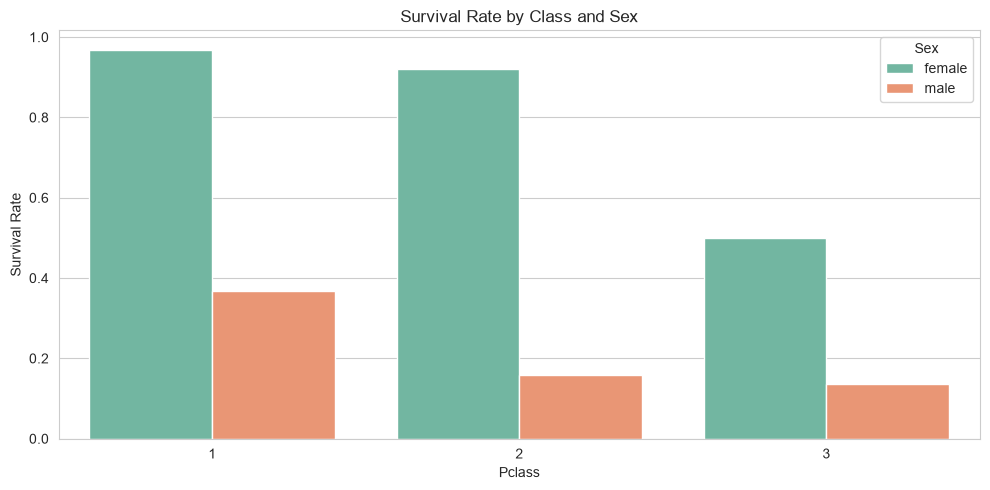

Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135


In [44]:
# Combined effect — barplot with hue
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex",
            palette="Set2", errorbar=None)
plt.title("Survival Rate by Class and Sex")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

# Cross-tab for exact numbers
print(pd.crosstab(df["Pclass"], df["Sex"], values=df["Survived"], aggfunc="mean").round(3))

##  Numeric Relationships — Scatter & Jointplot

For two numeric features, scatter plots show correlation.

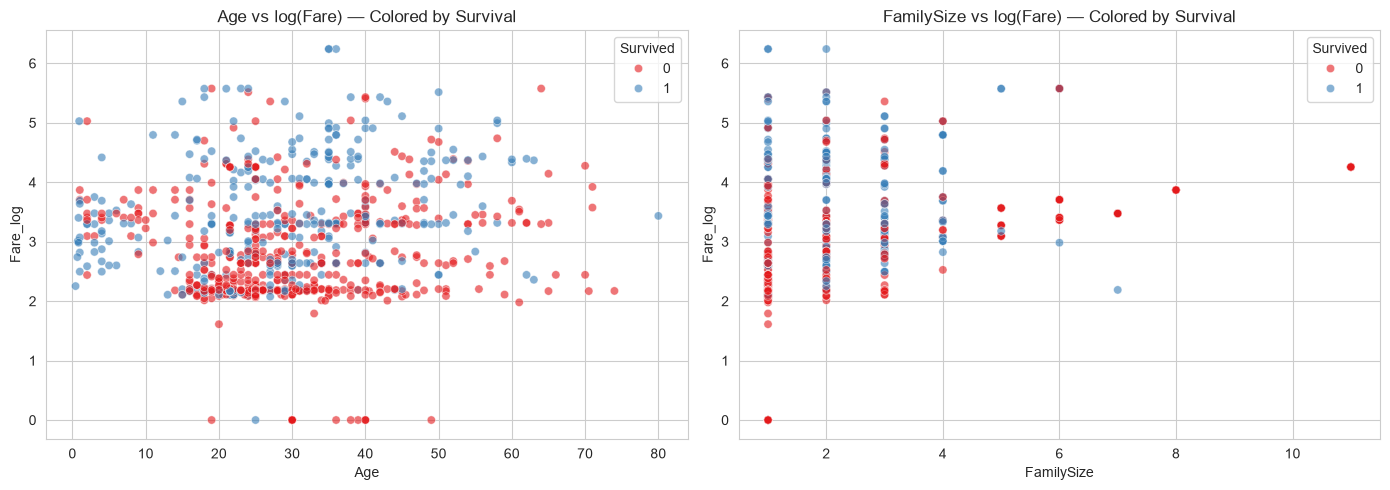

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age vs Fare, colored by survival
sns.scatterplot(data=df, x="Age", y="Fare_log", hue="Survived",
                alpha=0.6, ax=axes[0], palette="Set1")
axes[0].set_title("Age vs log(Fare) — Colored by Survival")

# Family size vs Fare
sns.scatterplot(data=df, x="FamilySize", y="Fare_log", hue="Survived",
                alpha=0.6, ax=axes[1], palette="Set1")
axes[1].set_title("FamilySize vs log(Fare) — Colored by Survival")

plt.tight_layout()
plt.show()

## Box Plots — Distribution by Group

Boxplot = median + IQR + outliers, per category. One of the most informative plots.

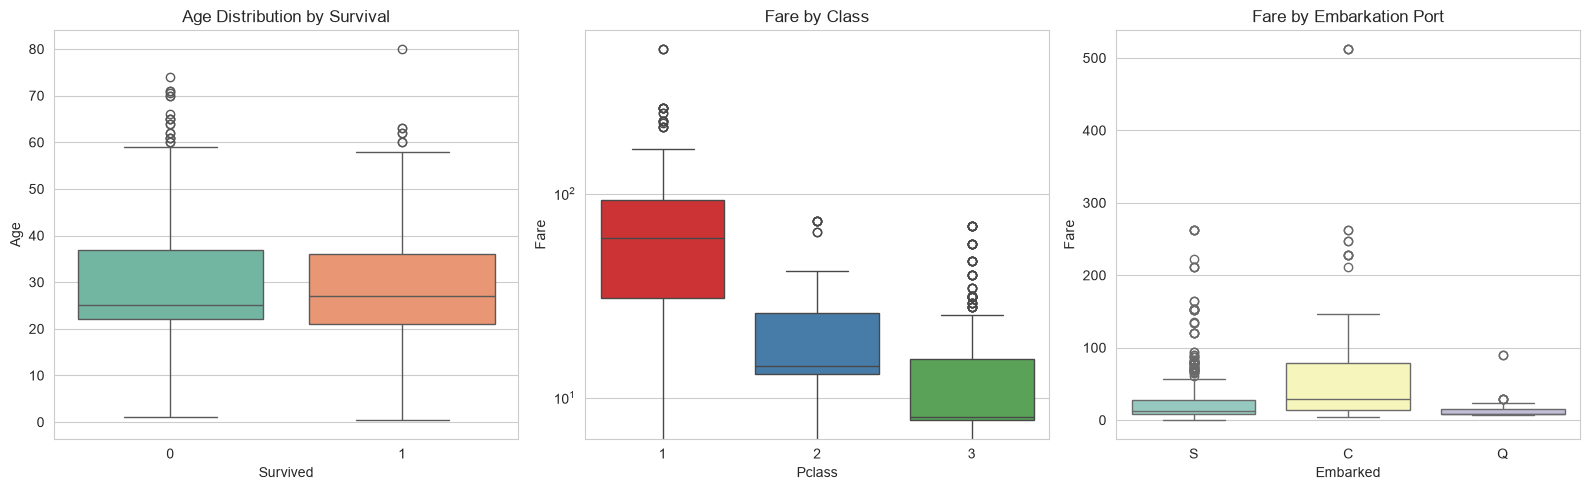

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="Survived", y="Age", ax=axes[0], hue="Survived",
            palette="Set2", legend=False)
axes[0].set_title("Age Distribution by Survival")

sns.boxplot(data=df, x="Pclass", y="Fare", ax=axes[1], hue="Pclass",
            palette="Set1", legend=False)
axes[1].set_title("Fare by Class")
axes[1].set_yscale("log")

sns.boxplot(data=df, x="Embarked", y="Fare", ax=axes[2], hue="Embarked",
            palette="Set3", legend=False)
axes[2].set_title("Fare by Embarkation Port")

plt.tight_layout()
plt.show()

##  Correlation Heatmap

For numeric features, correlation shows linear relationships at a glance.

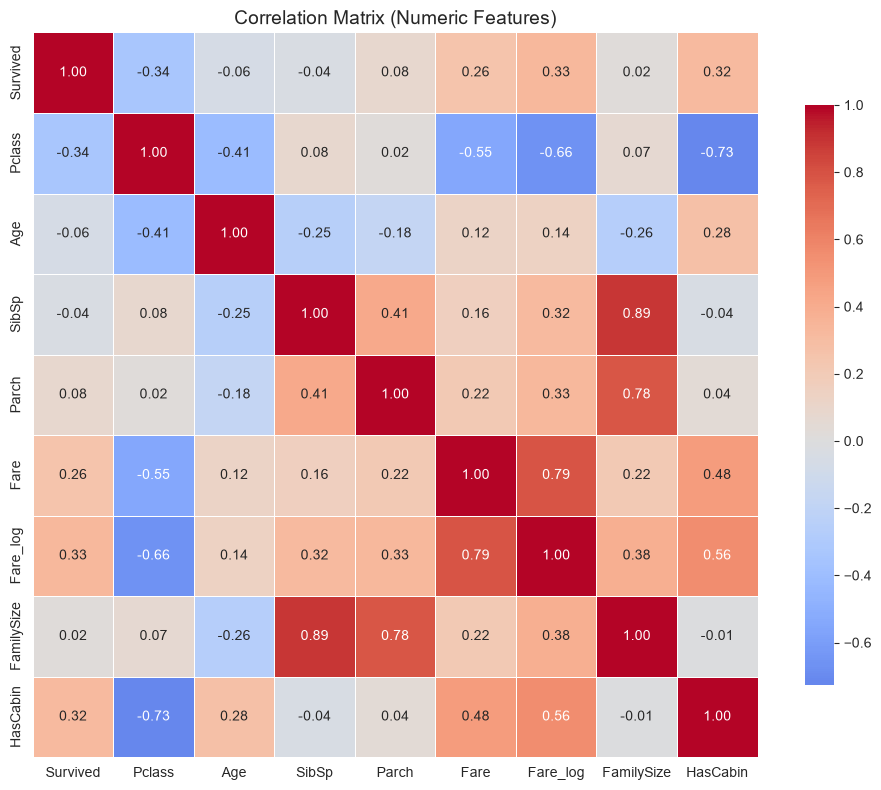

In [47]:
# Select numeric columns
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch",
                "Fare", "Fare_log", "FamilySize", "HasCabin"]
corr_matrix = df[numeric_cols].astype(float).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix (Numeric Features)", fontsize=14)
plt.tight_layout()
plt.show()

##  Pairplot — All-in-One Overview

Pairplot plots every numeric pair. Great for a first scan, but slow on large data.

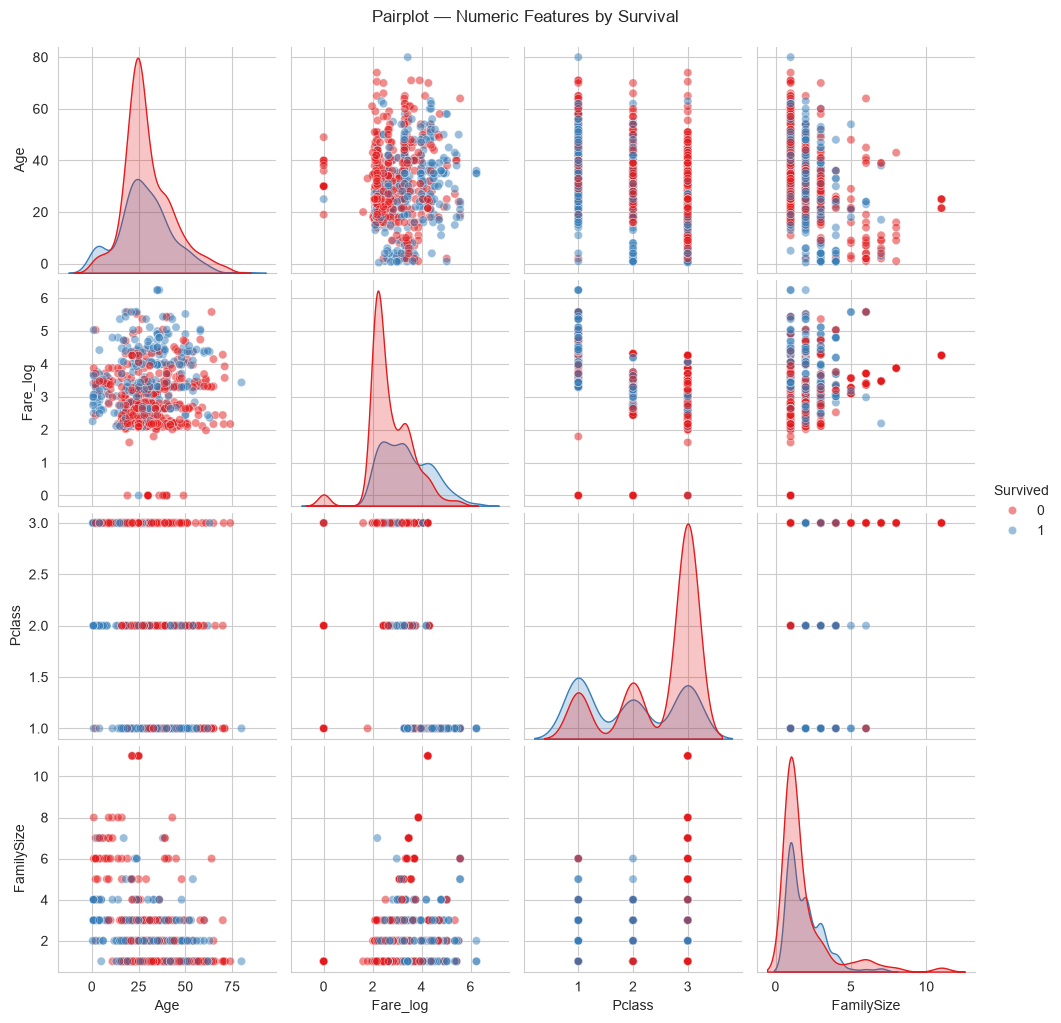

In [48]:
# Use a subset for speed and readability
pair_cols = ["Survived", "Age", "Fare_log", "Pclass", "FamilySize"]

sns.pairplot(df[pair_cols].astype({"Survived": int, "Pclass": int}),
             hue="Survived", palette="Set1",
              diag_kind="kde" ,plot_kws={"alpha": 0.5})
plt.suptitle("Pairplot — Numeric Features by Survival", y=1.02)
plt.show()

## 9. What We Learned


- **Distributions first**: raw `Fare` is skewed → `log1p` normalizes it.
- **Sex** is the strongest single predictor (~74٪ vs ~19٪ survival).
- **Pclass** matters, but interacts with `Sex` — `Sex` dominates.
- **Correlation heatmap** revealed multi-collinearity: `Fare` ↔ `Fare_log`, `SibSp` ↔ `FamilySize`.
- **Boxplots** quickly show distribution shifts across categories.

## 🚀 Next

→ [../02-preprocessing/01-missing-outliers.ipynb](../02-preprocessing/01-missing-outliers.ipynb): formal preprocessing pipeline with scaling, encoding, and dimensionality reduction.